# Notebook 01 — Data Preparation & Exploratory Analysis

## Business Context
This notebook prepares the simulation data generated by `data_pipeline.py`
for causal inference analysis.

A pricing pilot was conducted in **8 physical stores** across the Waterloo region
(Kitchener, Waterloo, Cambridge) during **Q2 2024 (April – June 2024)**.
The pilot applied a price change to three departments:
- **Electronics** (low price elasticity — expected revenue gain)
- **Home & Kitchen** (medium elasticity — expected small gain)
- **Sports & Outdoors** (high elasticity — expected revenue loss)

## Objective
Prepare a clean analytical table from the raw simulation data that will feed
into notebooks 02–06 for causal analysis using:
- A/B Test (t-test with power analysis)
- Difference-in-Differences (DiD)
- Synthetic Control
- Bayesian Structural Time Series (BSTS)
- Heterogeneous Treatment Effects (HTE Meta-learners)

## What This Notebook Does
1. **Load Raw Data** — 4 CSV tables from `data/`
2. **Data Quality Validation** — shape, nulls, dtypes, key value checks
3. **Exploratory Data Analysis** — revenue distributions, time series trends, parallel trends visual check, store-level analysis
4. **Store Similarity Matching** — match each pilot store to its closest control store using Euclidean distance on 3 features; saves updated `stores.csv`
5. **Build Combined Analytical Table** — aggregate daily → weekly, join all tables, save `data/analytical_table.csv` for downstream notebooks

## Data Sources
| File | Description | Rows |
|---|---|---|
| `stores.csv` | Store characteristics, pilot flags, matched control IDs | 20 |
| `dept.csv` | Department properties and price elasticity groups | 120 |
| `daily_sales.csv` | Daily revenue outcome with treatment effects baked in | 65,880 |
| `ground_truth.csv` | True ATT values — loaded only in Notebook 07, not used here | 3 |

## Key Design Decisions Reflected in This Notebook
- **Store 9 (Online-Waterloo) excluded** from all analysis — online pricing is national,
  not regional; including it would violate SUTVA
- **Parallel trends assumption validated visually** in Chart 2
- **Matching is post-hoc** — stores were pre-selected by business decision, not randomised;
  matching reduces but does not eliminate selection bias

In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None) # show all columns
# pd.set_option('display.float_format', '{:,.0}'.format)  # 2 decimal places
plt.style.use('seaborn-v0_8')  # clean chart style

print("Libraries loaded")


Libraries loaded


## Load Raw Data

In [278]:
stores_df = pd.read_csv('../data/stores.csv')
dept_df       = pd.read_csv('../data/dept.csv')
daily_sales_df = pd.read_csv('../data/daily_sales.csv', parse_dates=['dates', 'week_start_date'])
ground_truth  = pd.read_csv('../data/ground_truth.csv')

## Data Quality Validation

Verify each table loaded correctly:
- Correct shape (rows × columns)
- Column names and data types look right
- No unexpected nulls
- Key values make sense (e.g. pilot flags, date range)

In [279]:
print("=" * 50)
print("STORES TABLE")
print("=" * 50)
print(f"Shape: {stores_df.shape}  →  {stores_df.shape[0]} rows, {stores_df.shape[1]} columns")
print(f"Pilot stores (B&M only):  {stores_df['is_pilot'].sum()}")
print(f"\nControl stores:           {(~stores_df['is_pilot']).sum()}")
print(f'\nStores 9 pilot flag:')
print(stores_df[stores_df['store_id'] == 9][['store_id', 'store_name', 'is_pilot']])
print(f"\nData types:")
print(stores_df.dtypes)

STORES TABLE
Shape: (20, 9)  →  20 rows, 9 columns
Pilot stores (B&M only):  8

Control stores:           12

Stores 9 pilot flag:
   store_id       store_name  is_pilot
8         9  Online-Waterloo     False

Data types:
store_id                int64
store_name                str
city                      str
store_size_sqft         int64
weekly_footfall         int64
is_pilot                 bool
store_format              str
matched_control_id    float64
open_since                str
dtype: object


In [280]:
print("Null values per column:")
print(stores_df.isnull().sum())

Null values per column:
store_id               0
store_name             0
city                   0
store_size_sqft        0
weekly_footfall        0
is_pilot               0
store_format           0
matched_control_id    12
open_since             0
dtype: int64


In [281]:
# First 3 rows — Jupyter renders this as a proper table
stores_df.head(3)

,store_id,store_name,city,store_size_sqft,weekly_footfall,is_pilot,store_format,matched_control_id,open_since
0,1,Kitchener-Fairview,Kitchener,71422,6685,True,large,1e+01,2023-01-01
1,2,Kitchener-Stanley Park,Kitchener,30795,20668,True,medium,2e+01,2023-01-01
2,3,Kitchener-Downtown,Kitchener,15860,5769,True,small,1e+01,2023-01-01


In [282]:
print("=" * 50)
print("DEPARTMENTS TABLE")
print("=" * 50)
print(f"Shape: {dept_df.shape}")
print(f"\nNulls:\n{dept_df.isnull().sum()}")
print(f"\nPilot departments (rows): {dept_df['dept_pilot'].sum()} (expected 60)")
print(f"\nDept names: {dept_df['dept_name'].unique()}")
print(f"\nElasticity groups:\n{dept_df['price_elasticity_group'].value_counts()}")
dept_df.head(6)

DEPARTMENTS TABLE
Shape: (120, 5)

Nulls:
dept_id                   0
dept_name                 0
dept_pilot                0
store_id_dept             0
price_elasticity_group    0
dtype: int64

Pilot departments (rows): 60 (expected 60)

Dept names: <StringArray>
[      'Electronics',    'Home & Kitchen', 'Sports & Outdoors',
          'Clothing',             'Books',              'Toys']
Length: 6, dtype: str

Elasticity groups:
price_elasticity_group
Medium    80
Low       20
High      20
Name: count, dtype: int64


,dept_id,dept_name,dept_pilot,store_id_dept,price_elasticity_group
0,1,Electronics,True,1,Low
1,2,Home & Kitchen,True,1,Medium
2,3,Sports & Outdoors,True,1,High
3,4,Clothing,False,1,Medium
4,5,Books,False,1,Medium
5,6,Toys,False,1,Medium


In [283]:
print("=" * 50)
print("DAILY SALES TABLE")
print("=" * 50)
print(f"Shape: {daily_sales_df.shape}")
print(f"\nDate range: {daily_sales_df['dates'].min()} → {daily_sales_df['dates'].max()}")
print(f"\nNulls:\n{daily_sales_df.isnull().sum()}")
print(f"\nTreated rows:      {daily_sales_df['treated'].sum()}")
print(f"During pilot rows: {daily_sales_df['during_pilot'].sum()}")
print(f"Closed days (revenue=0): {(daily_sales_df['revenue'] == 0).sum()}")
print(f"\nRevenue stats:")
print(daily_sales_df['revenue'].round(0).describe().astype(int))
daily_sales_df['revenue'] = daily_sales_df['revenue'].round(0)
daily_sales_df.head(3).style.format({'revenue': '{:,.0f}', 'units_sold': '{:,.0f}'})

DAILY SALES TABLE
Shape: (65880, 11)

Date range: 2023-04-01 00:00:00 → 2024-09-30 00:00:00

Nulls:
store_id               0
dept_id                0
dates                  0
week_start_date        0
during_pilot           0
post_pilot             0
is_store_open          0
reason_closed      64320
treated                0
revenue                0
units_sold             0
dtype: int64

Treated rows:      2184
During pilot rows: 10920
Closed days (revenue=0): 1560

Revenue stats:
count    65880
mean      4402
std       3220
min          0
25%       1972
50%       3441
75%       6244
max      20926
Name: revenue, dtype: int64


,store_id,dept_id,dates,week_start_date,during_pilot,post_pilot,is_store_open,reason_closed,treated,revenue,units_sold
0,1,1,2023-04-01 00:00:00,2023-03-27 00:00:00,False,False,True,nan,False,"12,137",84
1,1,1,2023-04-02 00:00:00,2023-03-27 00:00:00,False,False,True,nan,False,"12,985",90
2,1,1,2023-04-03 00:00:00,2023-04-03 00:00:00,False,False,True,nan,False,"10,170",71


## Section 3 — Exploratory Data Analysis (EDA)

- Visual exploration before running causal models.
- Goal: understand revenue patterns, spot anomalies, 
- build intuition for what the causal analysis will find.

### Daily Reveneu Distribution per Department

In [284]:
# Join dept_df with dept_name for open days only
# dept_name_df = dept_df.groupby(['dept_id','dept_name', 'price_elasticity_group']).size().reset_index()
dept_name_df = dept_df[['dept_id', 'dept_name', 'price_elasticity_group']].drop_duplicates()

daily_rev_dist_dept_df = pd.merge(daily_sales_df, dept_name_df[['dept_id', 'dept_name', 'price_elasticity_group']], on='dept_id', how='left')
daily_rev_dist_dept_df.head(2)

,store_id,dept_id,dates,week_start_date,during_pilot,post_pilot,is_store_open,reason_closed,treated,revenue,units_sold,dept_name,price_elasticity_group
0,1,1,2023-04-01,2023-03-27,False,False,True,NaN,False,1e+04,84,Electronics,Low
1,1,1,2023-04-02,2023-03-27,False,False,True,NaN,False,1e+04,90,Electronics,Low


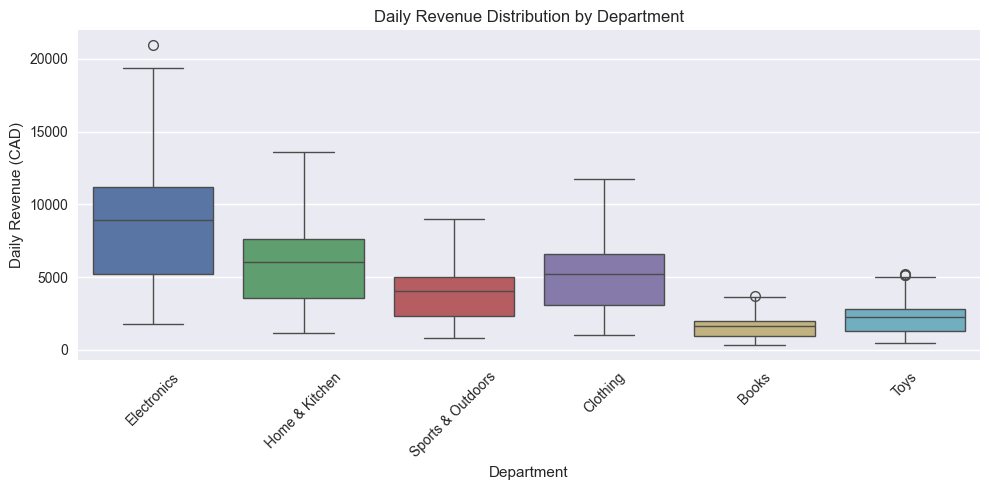

In [285]:
# Filter open days only
open_days_df = daily_rev_dist_dept_df[daily_rev_dist_dept_df['is_store_open'] == True]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data= open_days_df,           # which DataFrame?
    x= 'dept_name',              # department name column
    y= 'revenue',              # revenue column
    hue= 'dept_name',
    ax=ax
)

ax.set_title('Daily Revenue Distribution by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Daily Revenue (CAD)')
plt.xticks(rotation=45)   # rotate labels so they don't overlap
plt.tight_layout()
plt.show()

### Chart 1 Insights — Daily Revenue Distribution by Department

**What this shows:** Daily revenue distribution across all 18 months 
(Apr 2023 – Sep 2024), all stores combined, open days only.

**Key observations:**

1. **Revenue hierarchy matches simulation design** — Electronics has 
   the highest median (~$8,500/day), Books the lowest (~$1,500/day), 
   consistent with the department revenue midpoints set in data_pipeline.py.

2. **All distributions are right-skewed** — median sits closer to Q1 
   than Q3 for most departments. This reflects realistic retail patterns: 
   most days are average, but occasional spikes (Q4 holiday season, 
   large stores, weekends) create a long upper tail.

3. **Outliers are explainable** — Electronics shows one outlier above 
   $20k. This occurs when a large-format store (high size_factor) 
   coincides with a Q4 date (seasonality = 1.3×) and a weekend 
   (day_factor = 1.2×). Combined multiplier: 1.3 × 1.2 × large 
   size_factor = realistic spike.

4. **Treatment effect not visible here** — the +12% Electronics ATT 
   applies to only ~728 rows (1.1% of data). It is completely diluted 
   by the remaining 98.9% of pre-pilot and control observations. 
   The time series analysis (Chart 2) isolates this effect properly.

**Limitation:** This chart combines all time periods and all stores. 
It validates simulation design but cannot detect the causal effect.

In [286]:
daily_rev_dist_dept_df[
    (daily_rev_dist_dept_df['dept_name'] == 'Electronics') &
    (daily_rev_dist_dept_df['revenue'] > 20000)
]

,store_id,dept_id,dates,week_start_date,during_pilot,post_pilot,is_store_open,reason_closed,treated,revenue,units_sold,dept_name,price_elasticity_group
13428,5,1,2023-12-09,2023-12-04,False,False,True,NaN,False,2e+04,146,Electronics,Low


### Chart 2 -Revenue Time Series to know the Intervention Effect

This time series is **descriptive only** — it shows whether revenue 
visually changed around the intervention date but does not establish 
statistical significance or causation.

Two purposes:
1. **Parallel trends check** — in the pre-pilot period (shaded grey), 
   do pilot and control store lines move together? If yes, this 
   validates the DiD assumption in Notebook 03.
2. **Business visual** — provides intuition for stakeholders before 
   the formal causal analysis in Notebooks 02–05.

Statistical significance and causal attribution are established in 
subsequent notebooks.

In [287]:
# Aggregate to weekly level
# sum revenue per week per store-group per dept
# Filter open days only
open_days_df = daily_rev_dist_dept_df[daily_rev_dist_dept_df['is_store_open'] == True].copy()

# Bring in is_pilot from stores_df
open_days_df = open_days_df.merge(
    stores_df[['store_id', 'is_pilot']],
    on='store_id',
    how='left'
)

# Aggregate to weekly level
weekly_df = open_days_df.groupby(
    ['week_start_date', 'is_pilot', 'dept_name'],
    as_index=False
).agg(
    weekly_revenue=('revenue', 'mean')
)

# Fix revenue format
weekly_df['weekly_revenue'] = weekly_df['weekly_revenue'].round(0).astype(int)
weekly_df['week_start_date'] = pd.to_datetime(weekly_df['week_start_date'])


# Readable label — use is_pilot not during_pilot
weekly_df['store_group'] = weekly_df['is_pilot'].map(
    {True: 'Pilot Stores', False: 'Control Stores'}
)

print(weekly_df.shape)
weekly_df.head()

(960, 5)


,week_start_date,is_pilot,dept_name,weekly_revenue,store_group
0,2023-03-27,False,Books,1761,Control Stores
1,2023-03-27,False,Clothing,5761,Control Stores
2,2023-03-27,False,Electronics,9893,Control Stores
3,2023-03-27,False,Home & Kitchen,6709,Control Stores
4,2023-03-27,False,Sports & Outdoors,4301,Control Stores


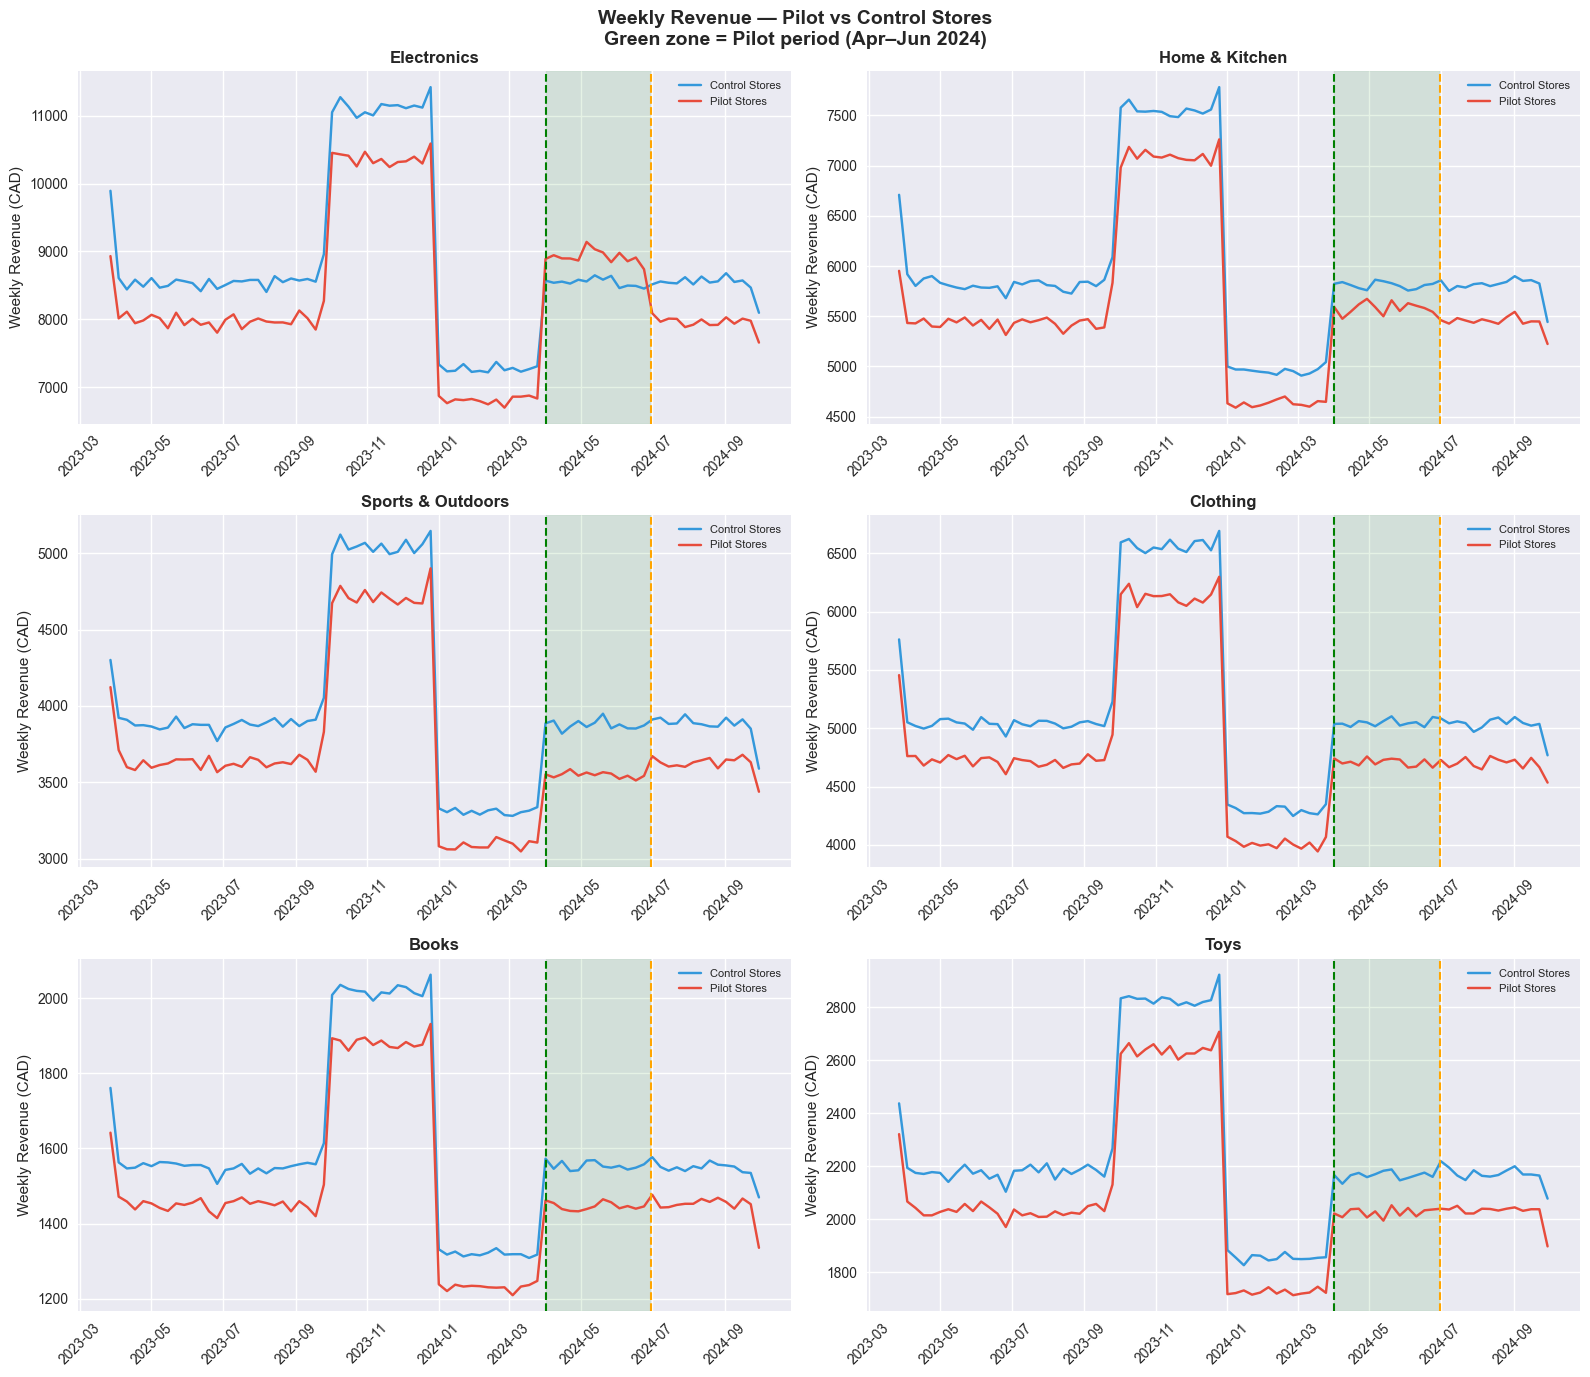

In [288]:
PILOT_START = pd.Timestamp("2024-04-01")
PILOT_END = pd.Timestamp("2024-06-30")

dept_order = ['Electronics', 'Home & Kitchen', 'Sports & Outdoors',
              'Clothing', 'Books', 'Toys']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, dept in enumerate(dept_order):
    ax = axes[i]
    dept_data = weekly_df[weekly_df['dept_name'] == dept]
    
    sns.lineplot(
        data=dept_data,
        x='week_start_date',
        y='weekly_revenue',
        hue='store_group',
        palette={'Pilot Stores': '#E74C3C', 'Control Stores': '#3498DB'},
        ax=ax
    )
    
    ax.axvline(x=PILOT_START, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(x=PILOT_END, color='orange', linestyle='--', linewidth=1.5)
    ax.axvspan(PILOT_START, PILOT_END, alpha=0.1, color='green')
    
    ax.set_title(f'{dept}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Weekly Revenue (CAD)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

fig.suptitle('Weekly Revenue — Pilot vs Control Stores\nGreen zone = Pilot period (Apr–Jun 2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 2 — Weekly Revenue: Pilot vs Control Stores by Department

Average weekly revenue per store, segmented by pilot vs control stores,
across all 6 departments over the full 18-month period (Apr 2023 – Sep 2024).
Green shaded zone = active pilot period (Apr–Jun 2024).

### Key Observations

**1. Parallel Trends hold in pre-pilot period (Apr 2023 – Mar 2024)**
Pilot and control store lines move together across all departments 


**2. Treatment effect visible during pilot (Apr–Jun 2024)**
- Electronics: pilot stores show a small upward divergence from 
  control stores 
- Sports & Outdoors: pilot stores drift slightly below control
- Home & Kitchen: minimal visible divergence 
- Clothing, Books, Toys: no divergence — correct, these departments 
  were not part of the pricing intervention

**3. Post-pilot revenue normalises (Jul–Sep 2024)**
Pilot store revenue drops back toward control levels after Jun 30, 2024,
suggesting the revenue lift was tied to the active intervention period.
This is consistent with prices reverting after the pilot ended.

**4. Jan 2024 drop visible in all departments**
Sharp revenue decline in January 2024 across all stores and departments.
Caused by the seasonality factor 

**5. Baseline gap between pilot and control stores**
Pilot stores (red) appear consistently below control stores (blue) 
in average daily revenue across the pre-period. This is likely due 
to random store size differences in the simulation — control stores 
may have received larger average store_size_sqft values by chance.
Store similarity matching will address 
this imbalance before causal analysis.

### Limitation
Effect sizes are subtle at weekly aggregation level and cannot be 
confirmed from visual inspection alone. 
This chart serves as visual hypothesis formation and parallel trends 
validation only.

### Chart 3 — Store-Level Weekly Revenue: Electronics Only (your current chart)

In [289]:
elec_weekly = (
    daily_sales_df[daily_sales_df['dept_id'] == 1]
        .groupby(['store_id', 'week_start_date'], as_index=False)['revenue']
.sum()
.rename(columns={'revenue':'weekly_revenue'})
)

elec_weekly['weekly_revenue'] = elec_weekly['weekly_revenue'].round(0).astype(int)

elec_weekly = elec_weekly.merge(
    stores_df[['store_id', 'store_name', 'is_pilot']],
    on='store_id', how='left'
)

In [290]:
elec_weekly

,store_id,week_start_date,weekly_revenue,store_name,is_pilot
0,1,2023-03-27,25122,Kitchener-Fairview,True
1,1,2023-04-03,66348,Kitchener-Fairview,True
2,1,2023-04-10,78808,Kitchener-Fairview,True
3,1,2023-04-17,76063,Kitchener-Fairview,True
4,1,2023-04-24,77799,Kitchener-Fairview,True
...,...,...,...,...,...
1595,20,2024-09-02,53368,Waterloo-Erbsville,False
1596,20,2024-09-09,62407,Waterloo-Erbsville,False
1597,20,2024-09-16,61230,Waterloo-Erbsville,False
1598,20,2024-09-23,63934,Waterloo-Erbsville,False


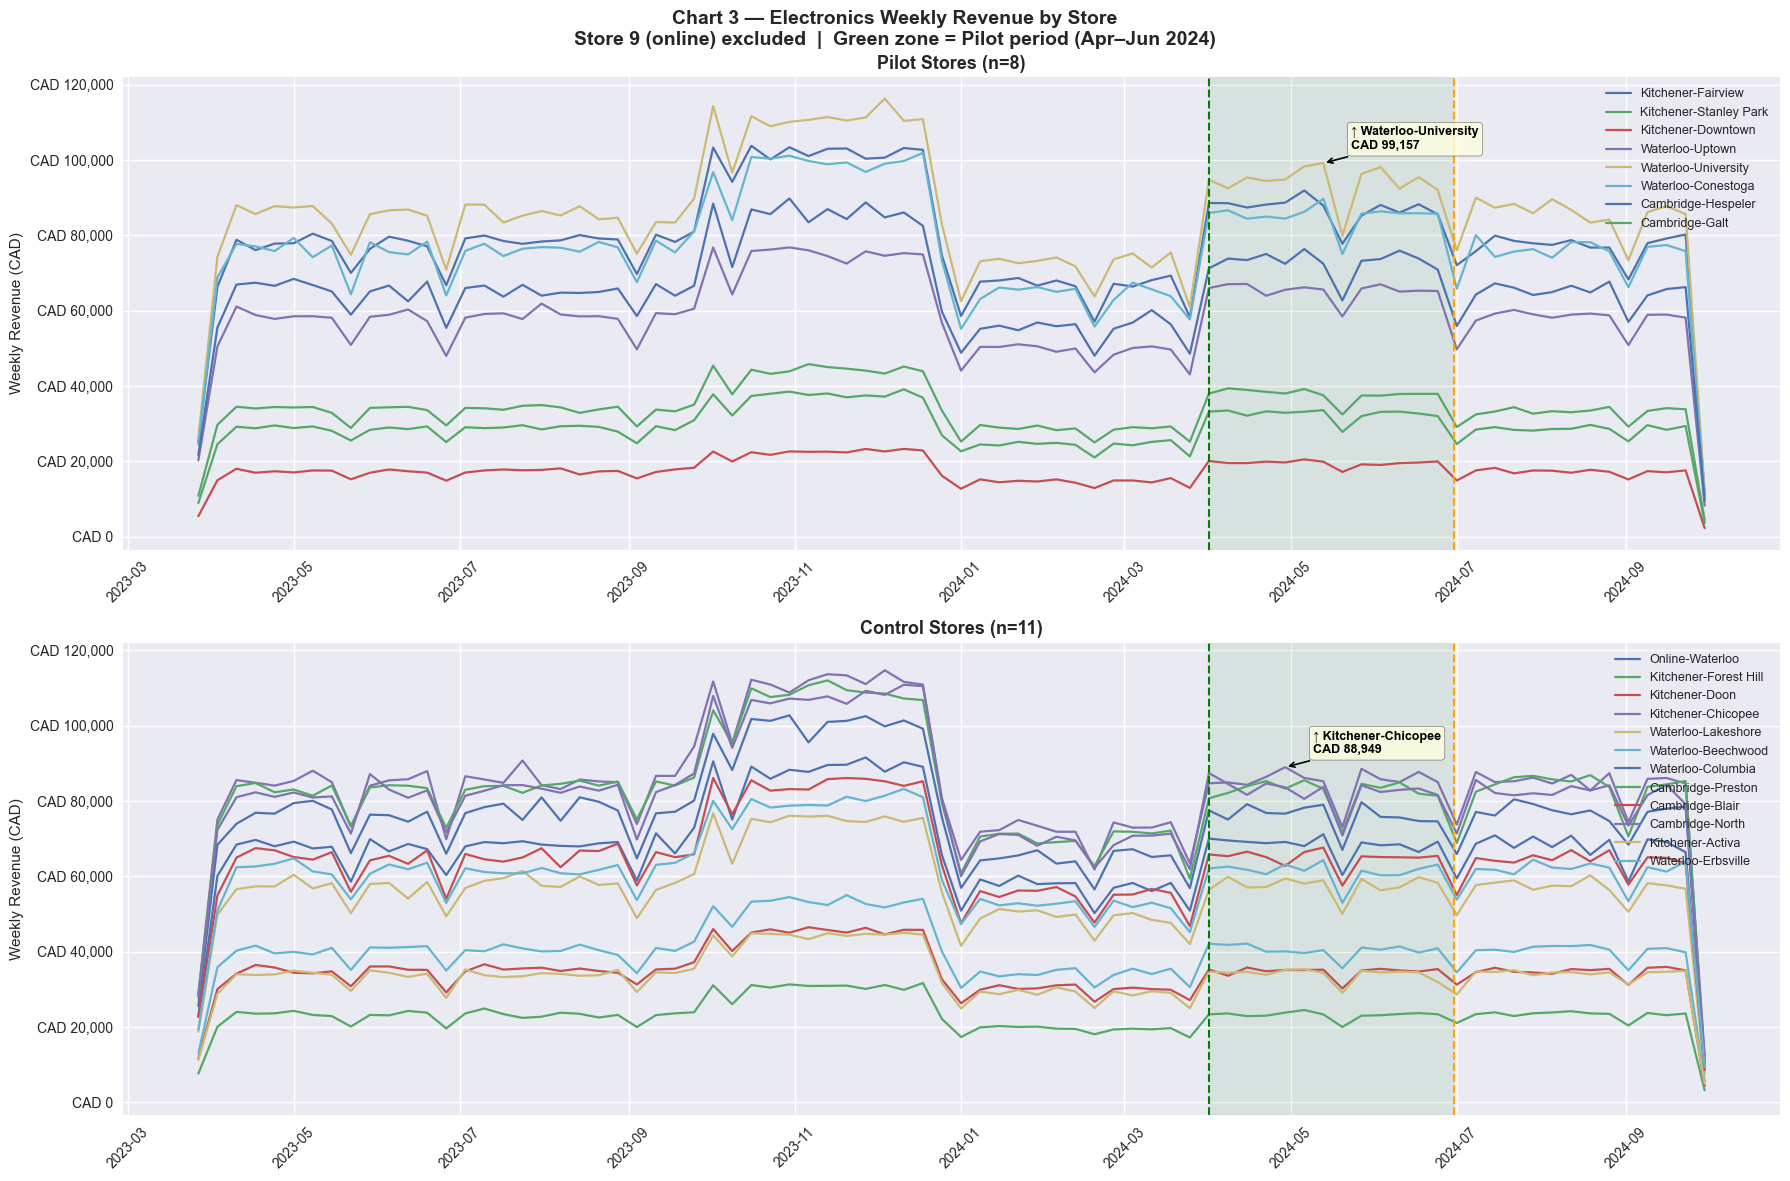


******************************************************************************************************************************************************
Top 3 Pilot Stores — Avg Weekly Revenue during Pilot:
         store_name  is_pilot  weekly_revenue
Waterloo-University      True           94111
 Kitchener-Fairview      True           87072
 Waterloo-Conestoga      True           85144

Top 3 Control Stores — Avg Weekly Revenue during Pilot:
        store_name  is_pilot  weekly_revenue
Kitchener-Chicopee     False           85036
 Cambridge-Preston     False           82440
   Cambridge-North     False           82399


In [291]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharey=True)
for ax, is_pilot_val, title in [
    (ax1, True,  'Pilot Stores (n=8)'),
    (ax2, False, 'Control Stores (n=11)'),
]:
    subset = elec_weekly[elec_weekly['is_pilot'] == is_pilot_val]
    pilot_avg = (
        subset[
            (subset['week_start_date'] >= PILOT_START) &
            (subset['week_start_date'] <= PILOT_END)
        ]
        .groupby('store_id')['weekly_revenue'].mean()
    )
    top_store_id = pilot_avg.idxmax()
    for store_id_val, grp in subset.groupby('store_id'):
        ax.plot(grp['week_start_date'], grp['weekly_revenue'],
                linewidth=1.6, label=grp['store_name'].iloc[0])
        if store_id_val == top_store_id:
            pilot_grp = grp[
                (grp['week_start_date'] >= PILOT_START) &
                (grp['week_start_date'] <= PILOT_END)
            ]
            peak_row = pilot_grp.loc[pilot_grp['weekly_revenue'].idxmax()]
            ax.annotate(
                f"↑ {grp['store_name'].iloc[0]}\nCAD {peak_row['weekly_revenue']:,.0f}",
                xy=(peak_row['week_start_date'], peak_row['weekly_revenue']),
                xytext=(20, 10), textcoords='offset points',
                fontsize=9, fontweight='bold', color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
            )
    ax.axvline(x=PILOT_START, color='green',  linestyle='--', linewidth=1.5)
    ax.axvline(x=PILOT_END,   color='orange', linestyle='--', linewidth=1.5)
    ax.axvspan(PILOT_START, PILOT_END, alpha=0.08, color='green')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Weekly Revenue (CAD)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'CAD {x:,.0f}'))
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle(
    'Chart 3 — Electronics Weekly Revenue by Store\n'
    'Store 9 (online) excluded  |  Green zone = Pilot period (Apr–Jun 2024)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\n' + '*'*150)

pilot_period = elec_weekly[
    (elec_weekly['week_start_date'] >= PILOT_START) &
    (elec_weekly['week_start_date'] <= PILOT_END)
]
top3 = (
    pilot_period
    .groupby(['store_name', 'is_pilot'])['weekly_revenue']
    .mean()
    .round(0)
    .reset_index()
    .sort_values('weekly_revenue', ascending=False)
)
top3['weekly_revenue'] = top3['weekly_revenue'].round(0).astype(int)

print("Top 3 Pilot Stores — Avg Weekly Revenue during Pilot:")
print(top3[top3['is_pilot'] == True].head(3).to_string(index=False))
print()
print("Top 3 Control Stores — Avg Weekly Revenue during Pilot:")
print(top3[top3['is_pilot'] == False].head(3).to_string(index=False))

### Chart 4 — Store-Level Weekly Revenue: Electronics Only

This chart filters daily sales to Electronics (dept 1), aggregates to weekly revenue,
and splits stores into Pilot (stores 1–8) and Control (stores 10–20). Store 9 (Online-Waterloo)
is excluded as its pricing is national, not regional, which would violate the study's SUTVA assumption.

**Key Insights:**
- **Waterloo-University** led all pilot stores with a peak weekly revenue of CAD 99,157 during the pilot period, visibly lifting above its own pre-period baseline at the green line.
- **The lift is broad, not concentrated** — top 3 pilot stores averaged CAD 94,111 / 87,072 / 85,144
  vs top 3 control stores at CAD 85,036 / 82,440 / 82,399, ruling out Simpson's Paradox.
- **Control stores showed no comparable lift** at the same point (top control: Kitchener-Chicopee at CAD 88,949), confirming the divergence is treatment-related, not seasonal noise.


## Section 4 — Store Similarity Matching

### What is store matching?
Store matching is a post-hoc technique used to identify the most similar control store
for each pilot store based on observable characteristics. It creates comparable pairs
so downstream analysis is fair — we are comparing apples to apples, not apples to oranges.

### Why is it needed here?
Stores 1–8 were pre-selected by a business decision, not randomly assigned to the pilot.
This means the pilot and control groups may be systematically different before treatment
even started — for example, Chart 4 showed pilot stores tend to have lower baseline revenue
than control stores, likely due to smaller average store size.

In a true randomised A/B test, matching would not be needed because randomisation already
ensures group comparability. Since this is an observational study simulating a real retail
rollout, we apply matching post-hoc to reduce selection bias.

### What are we matching on?
Three features, all z-score normalised so no single feature dominates by scale:

- **store_size_sqft** — physical store scale
- **weekly_footfall** — customer traffic volume
- **pre_period_avg_weekly_rev** — average weekly revenue Apr 2023 to Mar 2024,
  used as a proxy for overall store performance and implicit demographics
  (real study would also use median household income, population density,
  and competition density — not available in synthetic data)

### Method
Greedy 1:1 Euclidean distance matching on z-scored features. Each pilot store is matched
to the closest available control store. Once matched, a control store is removed from the
pool so no two pilot stores share the same match. Store 9 (Online-Waterloo) is excluded
from the matching pool entirely as it was excluded from the main analysis.

### How is the output used downstream?

| Notebook | Usage |
|---|---|
| 02 A/B test | Compare each pilot store only against its matched control store for a fairer t-test |
| 04 Synthetic Control | Matched control stores form the primary donor pool for building the synthetic counterfactual |

### Limitation
Matching reduces but does not eliminate selection bias. Unobserved differences between
stores — local competition, store management quality, neighbourhood demographics — cannot
be controlled for without richer data. This is acknowledged as a limitation of the study.


In [292]:
daily_sales_df_filtered = daily_sales_df[daily_sales_df['dates'] <= '2024-03-31'][['store_id','week_start_date','revenue']]


In [293]:
stores_filtered_df = stores_df[['store_id', 'store_name', 'store_size_sqft', 'weekly_footfall', 'is_pilot']]

In [294]:
avg_weekly_revenue = daily_sales_df_filtered.groupby(['store_id','week_start_date'])['revenue'].mean().reset_index()

In [295]:
avg_weekly_revenue_store = avg_weekly_revenue.groupby('store_id')['revenue'].mean().round(0).astype(int)

In [296]:
match_df = stores_filtered_df.merge(avg_weekly_revenue_store, on='store_id', how='left')

In [297]:
match_df = match_df[match_df['store_id'] != 9].reset_index(drop=True)
match_df = match_df.rename(columns={'revenue': 'pre_period_avg_weekly_rev'})
match_df.head(2)

,store_id,store_name,store_size_sqft,weekly_footfall,is_pilot,pre_period_avg_weekly_rev
0,1,Kitchener-Fairview,71422,6685,True,6022
1,2,Kitchener-Stanley Park,30795,20668,True,2595


In [298]:
features = ['store_size_sqft', 'weekly_footfall', 'pre_period_avg_weekly_rev']
for f in features:
    match_df[f+'_z'] = (match_df[f] - match_df[f].mean()) / match_df[f].std()        

In [299]:
match_df.head(2)

,store_id,store_name,store_size_sqft,weekly_footfall,is_pilot,pre_period_avg_weekly_rev,store_size_sqft_z,weekly_footfall_z,pre_period_avg_weekly_rev_z
0,1,Kitchener-Fairview,71422,6685,True,6022,0.9,-1e+00,0.9
1,2,Kitchener-Stanley Park,30795,20668,True,2595,-1e+00,1e+00,-1e+00


In [300]:
pilot_df   = match_df[match_df['is_pilot'] == True].reset_index(drop=True)
control_df = match_df[match_df['is_pilot'] == False].reset_index(drop=True)

In [301]:
from scipy.spatial.distance import cdist

z_features  = [f + '_z' for f in features]
dist_matrix = cdist(pilot_df[z_features].values, control_df[z_features].values, metric='euclidean')

matched_pairs = []
available = list(range(len(control_df)))

for i in range(len(pilot_df)):
    best = min(available, key=lambda j: dist_matrix[i, j])
    matched_pairs.append({
        'pilot_store_id':       pilot_df.loc[i, 'store_id'],
        'pilot_store_name':     pilot_df.loc[i, 'store_name'],
        'matched_control_id':   control_df.loc[best, 'store_id'],
        'matched_control_name': control_df.loc[best, 'store_name'],
        'distance_score':       round(dist_matrix[i, best], 3)
    })
    available.remove(best)

matches_df = pd.DataFrame(matched_pairs)
matches_df

,pilot_store_id,pilot_store_name,matched_control_id,matched_control_name,distance_score
0,1,Kitchener-Fairview,12,Kitchener-Chicopee,0.4
1,2,Kitchener-Stanley Park,19,Kitchener-Activa,0.05
2,3,Kitchener-Downtown,10,Kitchener-Forest Hill,0.9
3,4,Waterloo-Uptown,20,Waterloo-Erbsville,0.4
4,5,Waterloo-University,18,Cambridge-North,0.5
5,6,Waterloo-Conestoga,15,Waterloo-Columbia,0.8
6,7,Cambridge-Hespeler,13,Waterloo-Lakeshore,0.7
7,8,Cambridge-Galt,14,Waterloo-Beechwood,0.8


In [302]:
comparison = matches_df.merge(
    match_df[['store_id', 'store_size_sqft', 'weekly_footfall', 'pre_period_avg_weekly_rev']],
    left_on='pilot_store_id', right_on='store_id', how='left').rename(columns={
    'store_size_sqft': 'pilot_size',
    'weekly_footfall': 'pilot_footfall',
    'pre_period_avg_weekly_rev': 'pilot_rev'
}).drop(columns='store_id')

comparison = comparison.merge(
    match_df[['store_id', 'store_size_sqft', 'weekly_footfall', 'pre_period_avg_weekly_rev']],
    left_on='matched_control_id', right_on='store_id', how='left'
).rename(columns={
    'store_size_sqft': 'control_size',
    'weekly_footfall': 'control_footfall',
    'pre_period_avg_weekly_rev': 'control_rev'
}).drop(columns='store_id')

comparison['size_diff']     = (comparison['pilot_size'] - comparison['control_size']).abs()
comparison['footfall_diff'] = (comparison['pilot_footfall'] - comparison['control_footfall']).abs()
comparison['rev_diff']      = (comparison['pilot_rev'] - comparison['control_rev']).abs()

# print('\n' + '='*90)
# print('MATCHING QUALITY — FEATURE COMPARISON PER PAIR')
# print('='*90)
# print(comparison[[
#     'pilot_store_name', 'matched_control_name', 'distance_score',
#     'pilot_size', 'control_size', 'size_diff',
#     'pilot_footfall', 'control_footfall', 'footfall_diff',
#     'pilot_rev', 'control_rev', 'rev_diff'
# ]].to_string(index=False))
# print('='*90)
comparison

,pilot_store_id,pilot_store_name,matched_control_id,matched_control_name,distance_score,pilot_size,pilot_footfall,pilot_rev,control_size,control_footfall,control_rev,size_diff,footfall_diff,rev_diff
0,1,Kitchener-Fairview,12,Kitchener-Chicopee,0.4,71422,6685,6022,77678,6184,6540,6256,501,518
1,2,Kitchener-Stanley Park,19,Kitchener-Activa,0.05,30795,20668,2595,31023,20920,2616,228,252,21
2,3,Kitchener-Downtown,10,Kitchener-Forest Hill,0.9,15860,5769,1336,21265,10051,1791,5405,4282,455
3,4,Waterloo-Uptown,20,Waterloo-Erbsville,0.4,53158,15583,4474,56090,13666,4728,2932,1917,254
4,5,Waterloo-University,18,Cambridge-North,0.5,77570,18803,6541,75263,16096,6337,2307,2707,204
5,6,Waterloo-Conestoga,15,Waterloo-Columbia,0.8,69343,20773,5852,62191,17309,5231,7152,3464,621
6,7,Cambridge-Hespeler,13,Waterloo-Lakeshore,0.7,59732,11949,5032,52194,9555,4408,7538,2394,624
7,8,Cambridge-Galt,14,Waterloo-Beechwood,0.8,26284,7433,2212,36962,8385,3115,10678,952,903


In [303]:
stores_df.head()

,store_id,store_name,city,store_size_sqft,weekly_footfall,is_pilot,store_format,matched_control_id,open_since
0,1,Kitchener-Fairview,Kitchener,71422,6685,True,large,1e+01,2023-01-01
1,2,Kitchener-Stanley Park,Kitchener,30795,20668,True,medium,2e+01,2023-01-01
2,3,Kitchener-Downtown,Kitchener,15860,5769,True,small,1e+01,2023-01-01
3,4,Waterloo-Uptown,Waterloo,53158,15583,True,large,2e+01,2023-01-01
4,5,Waterloo-University,Waterloo,77570,18803,True,large,2e+01,2023-01-01


In [304]:
for i, row in matches_df.iterrows():
    # print(i,row)
    stores_df.loc[stores_df['store_id'] == row['pilot_store_id'], 'matched_control_id'] = row['matched_control_id']
    
stores_df['matched_control_id'] = stores_df['matched_control_id'].astype('Int64')
stores_df

,store_id,store_name,city,store_size_sqft,weekly_footfall,is_pilot,store_format,matched_control_id,open_since
0,1,Kitchener-Fairview,Kitchener,71422,6685,True,large,12,2023-01-01
1,2,Kitchener-Stanley Park,Kitchener,30795,20668,True,medium,19,2023-01-01
2,3,Kitchener-Downtown,Kitchener,15860,5769,True,small,10,2023-01-01
3,4,Waterloo-Uptown,Waterloo,53158,15583,True,large,20,2023-01-01
4,5,Waterloo-University,Waterloo,77570,18803,True,large,18,2023-01-01
5,6,Waterloo-Conestoga,Waterloo,69343,20773,True,large,15,2023-01-01
6,7,Cambridge-Hespeler,Cambridge,59732,11949,True,large,13,2023-01-01
7,8,Cambridge-Galt,Cambridge,26284,7433,True,small,14,2023-01-01
8,9,Online-Waterloo,Online,69886,10311,False,large,<NA>,2023-01-01
9,10,Kitchener-Forest Hill,Kitchener,21265,10051,False,small,<NA>,2023-01-01


In [305]:
stores_df.to_csv('../data/stores.csv', index=False)  

### Store Matching Results

**Method:** Greedy 1:1 Euclidean distance matching on 3 z-scored features:
store_size_sqft, weekly_footfall, pre_period_avg_weekly_rev (Apr 2023 – Mar 2024)

**Results:**

| Pilot Store | Matched Control | Distance | Quality |
|---|---|---|---|
| Kitchener-Stanley Park | Kitchener-Activa | 0.05 | Excellent |
| Kitchener-Fairview | Kitchener-Chicopee | 0.4 | Good |
| Waterloo-Uptown | Waterloo-Erbsville | 0.4 | Good |
| Waterloo-University | Cambridge-North | 0.5 | Acceptable |
| Cambridge-Hespeler | Waterloo-Lakeshore | 0.7 | Moderate |
| Waterloo-Conestoga | Waterloo-Columbia | 0.8 | Weak |
| Cambridge-Galt | Waterloo-Beechwood | 0.8 | Weak |
| Kitchener-Downtown | Kitchener-Forest Hill | 0.9 | Weakest |

**Key Observations:**
- 5 out of 8 matches have distance score below 0.7 — overall matching quality is acceptable
  given only 11 control stores were available
- Kitchener-Downtown is the weakest match (0.9) — it is the smallest pilot store at 15,860 sqft
  and no comparable small store existed in the control pool
- No score exceeds 1.0 — no catastrophically bad matches

**Limitation:**
Matching reduces but does not eliminate selection bias. Unobserved factors such as
neighbourhood demographics, local competition, and store management quality could not
be controlled for as this data is not available in the synthetic dataset.
In a production study, census income data and competition density would be added as
matching features.

**Unmatched control stores:** Kitchener-Doon, Cambridge-Preston, Cambridge-Blair
These 3 stores were not selected as matches but remain in the control pool and will
be used as donor candidates in Notebook 04 Synthetic Control.

## Section 5: Build Combined Analytical Table

In [306]:

# Aggregate daily → weekly and join all 4 tables into one clean
# analytical table. This feeds all causal notebooks 02–06.

# Aggregate daily to weekly
analytical_table = (
    daily_sales_df
    .groupby(['store_id', 'dept_id', 'week_start_date',
              'during_pilot', 'post_pilot', 'treated'], as_index=False)
    .agg(
        weekly_revenue = ('revenue',    'sum'),
        weekly_units   = ('units_sold', 'sum')
    )
)

# Join store metadata
analytical_table = analytical_table.merge(
    stores_df[['store_id', 'store_name', 'city', 'is_pilot',
               'store_format', 'matched_control_id']],
    on='store_id', how='left'
)

# Join department metadata
# Drop duplicates first — dept_df has one row per store × dept (120 rows)
# We only need dept-level info (6 unique rows)
dept_lookup = dept_df[['dept_id', 'dept_name', 'dept_pilot',
                        'price_elasticity_group']].drop_duplicates(subset=['dept_id'])

analytical_table = analytical_table.merge(
    dept_lookup,
    on='dept_id', how='left'
)

# Step 4 — Sort for readability
analytical_table = analytical_table.sort_values(
    ['store_id', 'dept_id', 'week_start_date']
).reset_index(drop=True)

# Step 5 — Save
analytical_table.to_csv('../data/analytical_table.csv', index=False)


print(f"Shape: {analytical_table.shape}")
print(f"Columns: {analytical_table.columns.tolist()}")
print(f"Date range: {analytical_table['week_start_date'].min()} to {analytical_table['week_start_date'].max()}")
print(f"Stores: {analytical_table['store_id'].nunique()}")
print(f"Departments: {analytical_table['dept_id'].nunique()}")
print(f"Weeks: {analytical_table['week_start_date'].nunique()}")
print(f"\nTreated rows: {analytical_table['treated'].sum()}")
analytical_table.head(3)

Shape: (9600, 16)
Columns: ['store_id', 'dept_id', 'week_start_date', 'during_pilot', 'post_pilot', 'treated', 'weekly_revenue', 'weekly_units', 'store_name', 'city', 'is_pilot', 'store_format', 'matched_control_id', 'dept_name', 'dept_pilot', 'price_elasticity_group']
Date range: 2023-03-27 00:00:00 to 2024-09-30 00:00:00
Stores: 20
Departments: 6
Weeks: 80

Treated rows: 312


,store_id,dept_id,week_start_date,during_pilot,post_pilot,treated,weekly_revenue,weekly_units,store_name,city,is_pilot,store_format,matched_control_id,dept_name,dept_pilot,price_elasticity_group
0,1,1,2023-03-27,False,False,False,3e+04,174,Kitchener-Fairview,Kitchener,True,large,12,Electronics,True,Low
1,1,1,2023-04-03,False,False,False,7e+04,463,Kitchener-Fairview,Kitchener,True,large,12,Electronics,True,Low
2,1,1,2023-04-10,False,False,False,8e+04,547,Kitchener-Fairview,Kitchener,True,large,12,Electronics,True,Low
